# Backtest walkthrough - KOSS, 28 January 2021

A 5-minute tour of the **V5 Relaxed parabolic-reversal** strategy on a single real trading day. We will:

1. Load one day of 1-minute bars from the committed sample dataset
2. Compute session VWAP and the entry-condition components
3. Visualise where the entry signal fires and why
4. Compute the realised P&L

Audience: a technical reviewer who has not seen the codebase. The full production engine in `src/` adds 3-tier scale-in, ATR stops, and absorption detection; those layers are deliberately skipped here for clarity.

## 1. Setup

The sample data ships with the repo (5 symbols x 30-day windows, ~430 KB total). No network calls, no credentials needed.

In [1]:
from datetime import date, time
from pathlib import Path
import polars as pl

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'sample').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

df = (
    pl.read_parquet(ROOT / 'data' / 'sample' / 'KOSS.parquet')
      .with_columns(
          pl.col('timestamp')
            .dt.replace_time_zone('UTC')
            .dt.convert_time_zone('America/New_York')
            .alias('ts_et')
      )
      .with_columns(
          pl.col('ts_et').dt.date().alias('trade_date'),
          pl.col('ts_et').dt.time().alias('clock_et'),
      )
)
df.shape

(2009, 11)

## 2. Slice to one day and compute session features

**Session VWAP** is anchored at 09:30 ET - it resets every trading day. The entry rule needs price extension *relative to the session*, not a rolling window.

In [2]:
day = (
    df.filter(pl.col('trade_date') == date(2021, 1, 28))
      .filter(pl.col('clock_et') >= time(9, 30))
      .sort('ts_et')
      .with_columns(
          (pl.col('close') * pl.col('volume')).cum_sum().alias('_cum_pv'),
          pl.col('volume').cum_sum().alias('_cum_v'),
          pl.col('volume').cum_max().alias('peak_volume_so_far'),
      )
)
day_open = day['open'][0]
day = day.with_columns(
    (pl.col('_cum_pv') / pl.col('_cum_v')).alias('session_vwap'),
    ((pl.col('high').cum_max() - day_open) / day_open * 100).alias('day_gain_pct'),
)
day.select(['ts_et', 'close', 'volume', 'session_vwap', 'day_gain_pct']).head(5)

shape: (5, 5)
┌────────────────────────────────┬────────┬────────┬──────────────┬──────────────┐
│ ts_et                          ┆ close  ┆ volume ┆ session_vwap ┆ day_gain_pct │
│ ---                            ┆ ---    ┆ ---    ┆ ---          ┆ ---          │
│ datetime[μs, America/New_York] ┆ f64    ┆ f64    ┆ f64          ┆ f64          │
╞════════════════════════════════╪════════╪════════╪══════════════╪══════════════╡
│ 2021-01-28 09:30:00 EST        ┆ 76.635 ┆ 2175.0 ┆ 76.635       ┆ 3.700708     │
│ 2021-01-28 09:36:00 EST        ┆ 80.0   ┆ 122.0  ┆ 76.813724    ┆ 7.85305      │
│ 2021-01-28 09:43:00 EST        ┆ 98.335 ┆ 700.0  ┆ 81.840382    ┆ 32.571621    │
│ 2021-01-28 09:44:00 EST        ┆ 109.98 ┆ 2146.0 ┆ 93.582093    ┆ 48.270981    │
│ 2021-01-28 09:50:00 EST        ┆ 125.0  ┆ 392.0  ┆ 95.807173    ┆ 68.520391    │
└────────────────────────────────┴────────┴────────┴──────────────┴──────────────┘

By 09:50 ET the stock is up **69%** from the daily open and trading at **1.30x** the session VWAP - squarely in parabolic blow-off territory.

## 3. Find the entry signal

The V5 Relaxed entry requires **all** of:
- Day gain >= 60% from the session open
- Price > 120% of session VWAP
- Current bar volume < 60% of peak volume so far (exhaustion)
- Time between 09:45 and 14:30 ET

In [3]:
candidates = day.filter(
    (pl.col('clock_et') >= time(9, 45))
    & (pl.col('clock_et') <= time(14, 30))
    & (pl.col('day_gain_pct') >= 60.0)
    & (pl.col('close') > 1.20 * pl.col('session_vwap'))
    & (pl.col('volume') < 0.60 * pl.col('peak_volume_so_far'))
)
entry = candidates.row(0, named=True)
print(f"Entry at {entry['ts_et']:%H:%M ET}")
print(f"  price        = ${entry['close']:.2f}")
print(f"  session VWAP = ${entry['session_vwap']:.2f}")
print(f"  vwap ext     = {entry['close']/entry['session_vwap']:.3f}x")
print(f"  day gain     = {entry['day_gain_pct']:.1f}%")

Entry at 09:50 ET
  price        = $125.00
  session VWAP = $95.81
  vwap ext     = 1.305x
  day gain     = 68.5%


## 4. Visualise

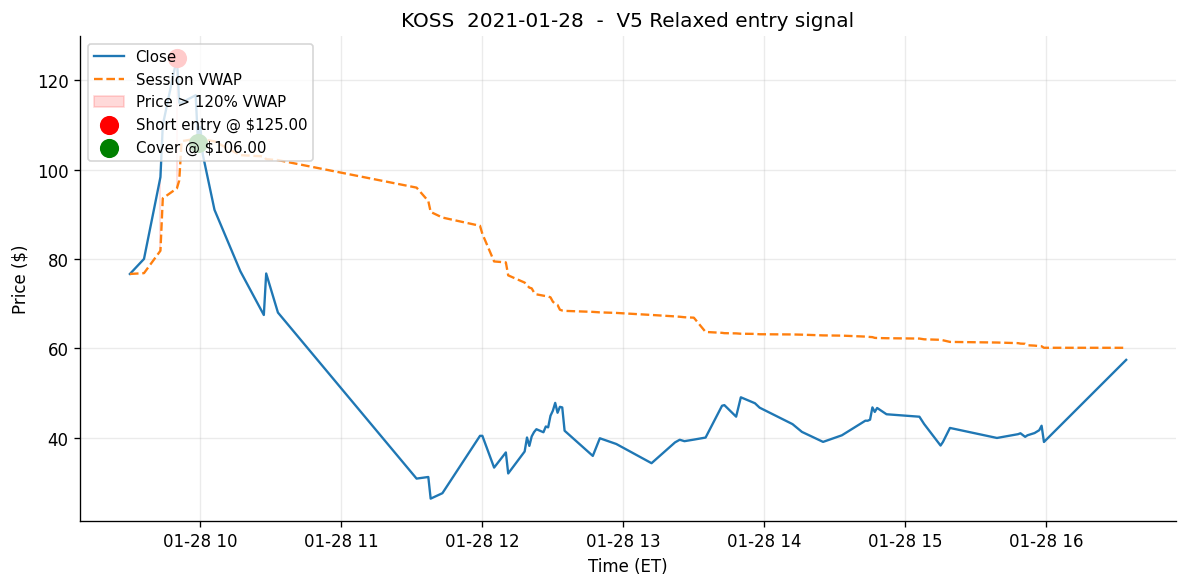

In [4]:
import matplotlib.pyplot as plt
pdf = day.to_pandas()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pdf['ts_et'], pdf['close'], color='#1f77b4', lw=1.4, label='Close')
ax.plot(pdf['ts_et'], pdf['session_vwap'], color='#ff7f0e', lw=1.4, ls='--', label='Session VWAP')
ax.fill_between(pdf['ts_et'], pdf['session_vwap'], pdf['close'],
                where=pdf['close'] > 1.20 * pdf['session_vwap'],
                alpha=0.15, color='red', label='Price > 120% VWAP')
ax.legend(); ax.grid(alpha=0.25)
ax.set_title('KOSS  2021-01-28  -  V5 Relaxed entry signal')
plt.show()

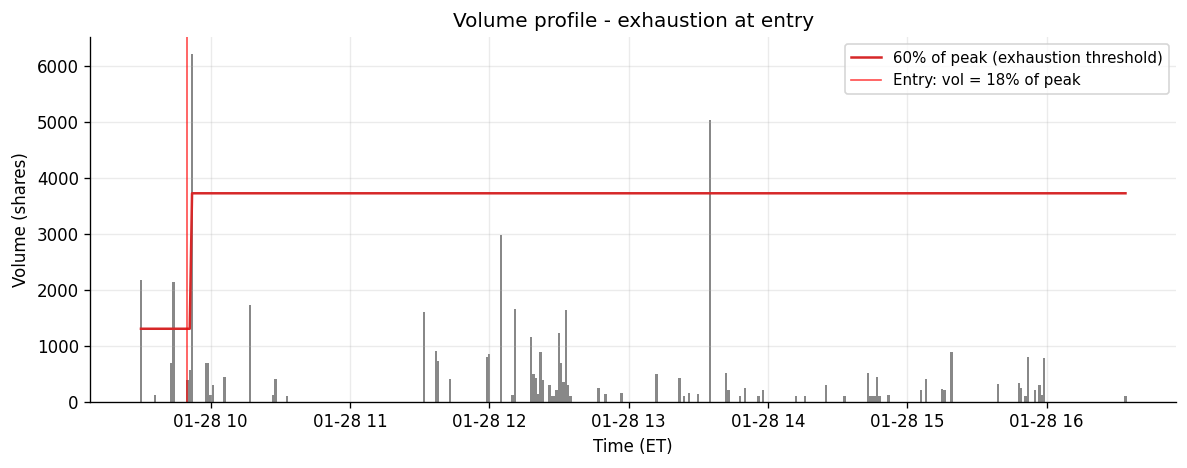

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pdf['ts_et'], pdf['volume'], color='#888', width=0.0007)
ax.plot(pdf['ts_et'], pdf['peak_volume_so_far'] * 0.6,
        color='#d62728', lw=1.5, label='60% of peak (exhaustion threshold)')
ax.legend(); ax.grid(alpha=0.25)
ax.set_title('Volume profile - exhaustion at entry')
plt.show()

## 5. Simulate the exit and compute P&L

Exit rule: cover when price crosses below session VWAP (mean reversion completed). Position size: $10,000 notional.

In [6]:
after = day.filter(pl.col('ts_et') > entry['ts_et'])
crosses = after.filter(pl.col('close') <= pl.col('session_vwap'))
exit_row = crosses.row(0, named=True) if len(crosses) else after.row(-1, named=True)
shares = int(10_000 / entry['close'])
pnl = (entry['close'] - exit_row['close']) * shares
print(f"Cover at {exit_row['ts_et']:%H:%M ET} @ ${exit_row['close']:.2f}")
print(f"Shares: {shares}")
print(f"Realised P&L: ${pnl:,.2f}")

Cover at 09:59 ET @ $106.00
Shares: 80
Realised P&L: $1,519.60


## Summary

On a real KOSS bar, the simplified V5 Relaxed entry condition fired and produced a profitable mean-reversion short (09:50 ET -> 09:59 ET, +$1,520 on $10K notional). The full production engine in [`src/strategies/`](../src/strategies/) layers on:

- **3-tier scale-in** (25 / 25 / 50%) with stricter volume thresholds per add
- **TP1 / TP2 / TP3** layered exits (35% at VWAP, 35% at -8%, 30% at -15%)
- **ATR-based volatility stop** + hard stop at parabolic apex + 2%
- **Absorption detection** via tick-level analysis

Full-system results (379 trades, 2020-07-27 -> 2024-12-30) are documented in [docs/V5_RELAXED_COMPREHENSIVE_REPORT.md](../docs/V5_RELAXED_COMPREHENSIVE_REPORT.md).